In [62]:
#primero importar lo que vamos a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
#estamos leyendo los csv y poniendolos con type diferente
redwine = pd.read_csv("winequality-red.csv", sep=";")
whitewine = pd.read_csv("winequality-white.csv", sep=";")

redwine["type"] = "red"
whitewine["type"] = "white"

df = pd.concat([redwine, whitewine], ignore_index=True)
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [64]:
#observamos los tipos de variable de cada uno
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

In [65]:
#borramos los datos nulos o vacios 
df_limpio = df.dropna()

print(df_limpio)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

In [66]:
#sacamos el porcentaje de los tipos de vinos 
df_limpio["type"].value_counts(normalize=True) * 100

type
white    75.388641
red      24.611359
Name: proportion, dtype: float64

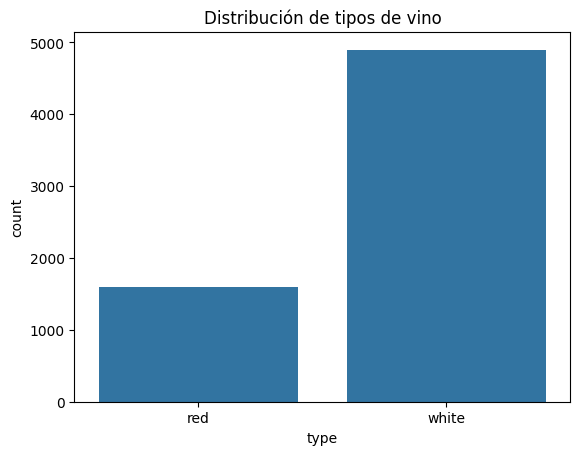

In [67]:
#vemos en la grafica cuantos vinos de cada tipo hay 
sns.countplot(x="type", data=df_limpio)

plt.title("Distribución de tipos de vino")
plt.show()

In [68]:
#observamos que hay mas vinos blancos que vinos rojos

In [69]:
#agrupamos pór la calidad de cada uno de los tipos de vino 
df_limpio.groupby("type")["quality"].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [70]:
#el vino blanco tiene mejor calidad que el vino rojo


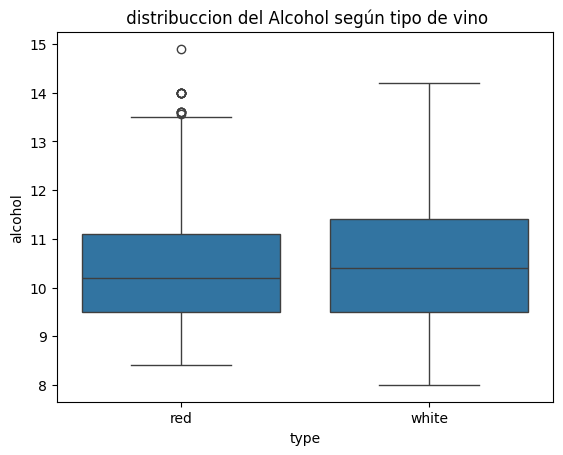

In [71]:
#hacemos un boxplot para observar la correlacion entre tipo y alcohol
sns.boxplot(
    x="type",
    y="alcohol",
    data=df_limpio
)

plt.title(" distribuccion del Alcohol según tipo de vino")
plt.show()

In [72]:
#Los vinos rojos presentan una mayor variabilidad en el contenido alcoholico con respecto a los vinos blancos.
#ya que observamos que tiene mas valores atipicos y tambien podemos evidenciar que la media del blanco es mayor a la del rojo 

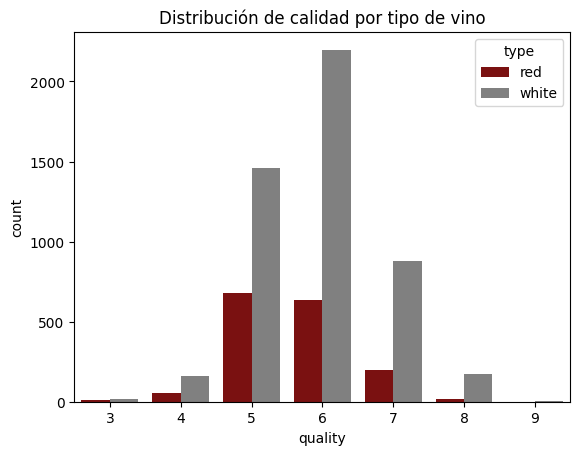

In [73]:
#con un countplot para mirarla diferencia de calidad con tipo de vino 
sns.countplot(
    x="quality",
    data=df_limpio,
    hue="type",
      palette={"red": "darkred", "white": "grey"}
)

plt.title("Distribución de calidad por tipo de vino")
plt.show()

In [74]:
#Se observa que la distribución de la calidad varía entre vinos rojos y blancos, 
# donde los vinos blancos tienden a concentrarse en valores de calidad ligeramente superiores,
#  mientras que los tintos presentan mayor dispersión.

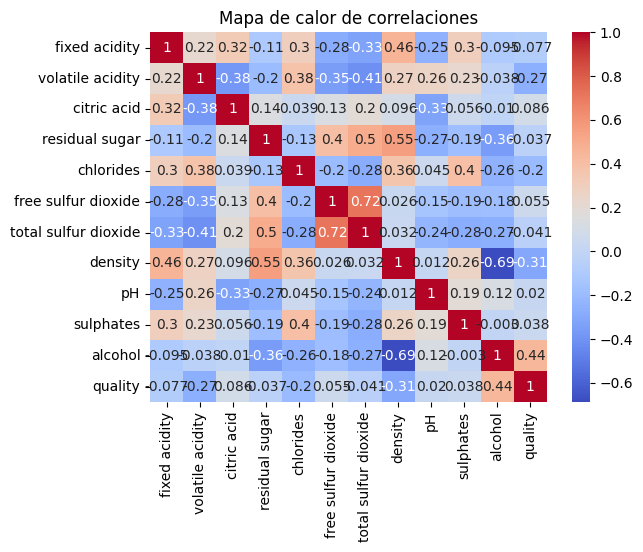

In [75]:
#hacemos un mapa de calor para observas las correlaciones entre todas las variables para ver si hay una que influye con la calidad  
corr = df_limpio.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    
)

plt.title("Mapa de calor de correlaciones")
plt.show()

In [76]:


#El dataset presenta relaciones químicas coherentes entre variables, aunque la calidad del vino no depende de una sola variable, 
# sino de múltiples factores combinados.

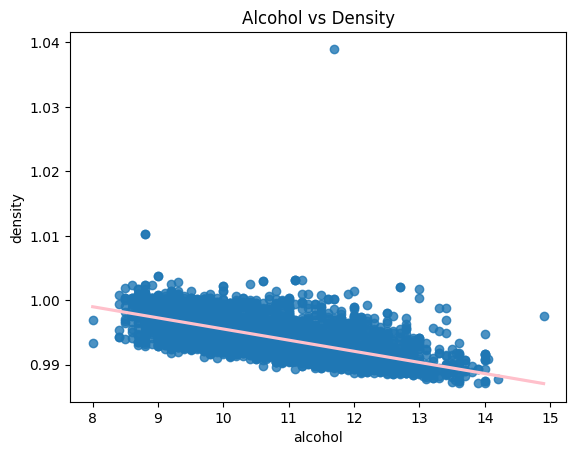

In [77]:
#hacemos una relacion lineal para ver como se comporta el alcohol con la densidad 
sns.regplot(
    x="alcohol",
    y="density",
    data=df_limpio,
  
    line_kws={"color":"pink"}
)

plt.title("Alcohol vs Density")
plt.show()

In [78]:
#A mayor contenido de alcohol, menor es la densidad del vino,


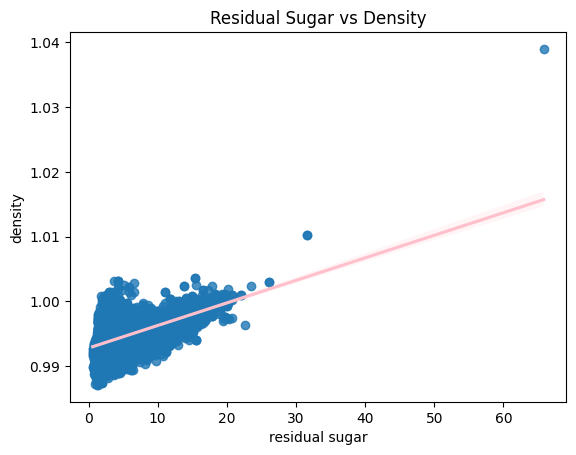

In [79]:
#hacemos una relacion lineal para ver como se comporta el azucar con la densidad
sns.regplot(
    x="residual sugar",
    y="density",
    data=df_limpio,
    line_kws={"color":"pink"}
)

plt.title("Residual Sugar vs Density")
plt.show()

In [80]:
#El contenido de azúcar residual incrementa la densidad del vino,
